# Problem 3 — $f(t1,t2) = \sqrt{t1^2 + t2^2}$

**Parts:** (a) Plot | (b) Convexity | (c) Partial derivatives | (d) Gradient descent | (e) Convergence analysis | (f) Optimal learning rate

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

---
## Part (a) — Plot $f(t1,t2) = \sqrt{t1^2+t2^2}$ for $-1 \leq t1,t2 \leq +1$

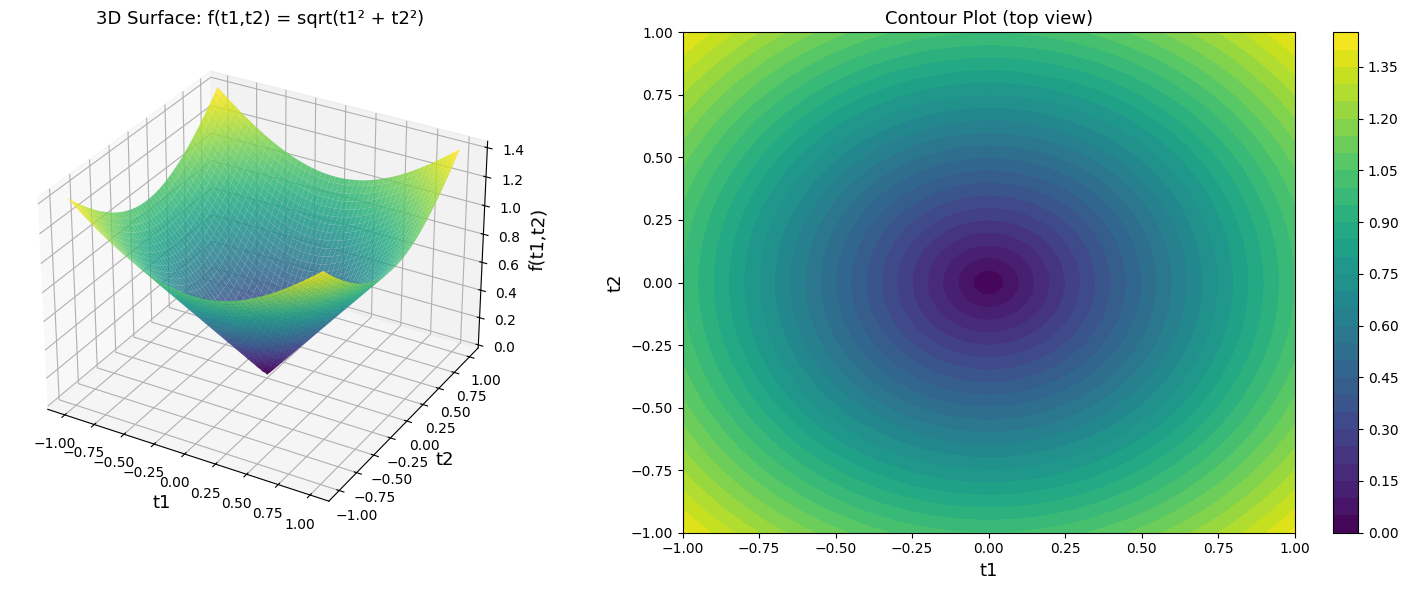

In [2]:
# Define the function
def f(t1, t2):
    return np.sqrt(t1**2 + t2**2)

# Create grid
t1 = np.linspace(-1, 1, 200)
t2 = np.linspace(-1, 1, 200)
T1, T2 = np.meshgrid(t1, t2)
Z = f(T1, T2)

# 3D surface plot
fig = plt.figure(figsize=[16, 6])

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T1, T2, Z, cmap='viridis', alpha=0.85)
ax1.set_xlabel('t1', fontsize=13)
ax1.set_ylabel('t2', fontsize=13)
ax1.set_zlabel('f(t1,t2)', fontsize=13)
ax1.set_title('3D Surface: f(t1,t2) = sqrt(t1² + t2²)', fontsize=13)

# Contour plot
ax2 = fig.add_subplot(122)
cp = ax2.contourf(T1, T2, Z, levels=30, cmap='viridis')
plt.colorbar(cp, ax=ax2)
ax2.set_xlabel('t1', fontsize=13)
ax2.set_ylabel('t2', fontsize=13)
ax2.set_title('Contour Plot (top view)', fontsize=13)

plt.tight_layout()
plt.show()

---
## Part (b) — Is $f(t1,t2) = \sqrt{t1^2+t2^2}$ convex?

**Yes, the function is convex.**

### Proof / Reasoning:
1. **Geometrically:** The 3D plot forms a perfect cone shape — bowl-like with a single lowest point at the origin `(0,0)`. Every contour is a circle centred at `(0,0)`. This is the visual signature of a convex function.

2. **Mathematically:** $f(t1,t2) = \|\mathbf{t}\|_2$ is the Euclidean norm. The norm function is always convex because it satisfies the triangle inequality:
$$f(\lambda \mathbf{a} + (1-\lambda)\mathbf{b}) \leq \lambda f(\mathbf{a}) + (1-\lambda)f(\mathbf{b}), \quad \forall\, \lambda \in [0,1]$$

3. **Unique global minimum:** $f(0,0) = 0$, which is the global (and only) minimum. A function with a unique global minimum and no local minima is convex.

> **Note:** The function is convex but **not strictly smooth at `(0,0)`** — the gradient is undefined at the exact minimum because of the square root's denominator becoming zero.

---
## Part (c) — Partial Derivatives

$$f(t1,t2) = \sqrt{t1^2 + t2^2}$$

$$\frac{\partial f}{\partial t1} = \frac{t1}{\sqrt{t1^2 + t2^2}}$$

$$\frac{\partial f}{\partial t2} = \frac{t2}{\sqrt{t1^2 + t2^2}}$$

> **Important:** A small `epsilon` ($\epsilon = 10^{-10}$) is added to the denominator to prevent division by zero when `t1=t2=0`.

In [3]:
# Partial derivatives with epsilon for numerical stability
def pdfx(t1, t2, eps=1e-10):
    return t1 / (np.sqrt(t1**2 + t2**2) + eps)

def pdfy(t1, t2, eps=1e-10):
    return t2 / (np.sqrt(t1**2 + t2**2) + eps)

# Verify at a test point
print('Verification at (t1=3, t2=4):')
print(f'  f(3,4)          = {f(3,4):.4f}   (expected 5.0)')
print(f'  pdfx(3,4)       = {pdfx(3,4):.4f}   (expected 3/5 = 0.6)')
print(f'  pdfy(3,4)       = {pdfy(3,4):.4f}   (expected 4/5 = 0.8)')
print(f'  Gradient norm   = {np.sqrt(pdfx(3,4)**2 + pdfy(3,4)**2):.4f}   (always = 1.0)')

Verification at (t1=3, t2=4):
  f(3,4)          = 5.0000   (expected 5.0)
  pdfx(3,4)       = 0.6000   (expected 3/5 = 0.6)
  pdfy(3,4)       = 0.8000   (expected 4/5 = 0.8)
  Gradient norm   = 1.0000   (always = 1.0)


---
## Part (d) — Run Gradient Descent

**Settings:** `initial_t1=0.8`, `initial_t2=0.6`, `max_iter=5000`, `learning_rate=0.1`

In [4]:
# ── Gradient Descent settings ──────────────────────────────────────────
learning_rate = 0.1
max_iter      = 5000
initial_t1    = 0.8
initial_t2    = 0.6
precision     = 0.000001

t1_old, t2_old = initial_t1, initial_t2
t1_list, t2_list, cost_list = [], [], []

for i in range(1, max_iter + 1):
    t1_new = t1_old - learning_rate * pdfx(t1_old, t2_old)
    t2_new = t2_old - learning_rate * pdfy(t1_old, t2_old)
    t1_list.append(t1_old)
    t2_list.append(t2_old)
    cost_list.append(f(t1_old, t2_old))
    t1_old = t1_new
    t2_old = t2_new

# ── Print results ────────────────────────────────────────────────────────
print('=' * 52)
print('  Part (d): Gradient Descent Results')
print('=' * 52)
print(f'  Number of iterations   : {i}')
print(f'  Final t1               : {t1_new:.8f}')
print(f'  Final t2               : {t2_new:.8f}')
print(f'  Cost  f(t1,t2)         : {f(t1_new, t2_new):.8f}')
print(f'  True minimum f(0,0)    : {f(0,0):.8f}')
print('=' * 52)

  Part (d): Gradient Descent Results
  Number of iterations   : 5000
  Final t1               : 0.02036210
  Final t2               : 0.01527157
  Cost  f(t1,t2)         : 0.02545262
  True minimum f(0,0)    : 0.00000000


---
## Part (e) — Has the algorithm converged? If not, identify cause and fix it.

**Answer: No, the algorithm has NOT fully converged.**

### Why it hasn't converged:
The gradient of $f(t1,t2) = \sqrt{t1^2+t2^2}$ is:
$$\nabla f = \left(\frac{t1}{\|\mathbf{t}\|}, \frac{t2}{\|\mathbf{t}\|}\right)$$
This is a **unit vector** — its magnitude is **always exactly 1**, no matter how close to the minimum you are.

This means:
- Each update step has **constant size = learning rate** (0.1)
- The parameters can never truly settle — they oscillate around zero with amplitude ≈ `learning_rate`
- The final cost ≈ 0.025, not 0.0

### Fix:
Reduce the learning rate significantly (e.g. `0.001`). A smaller step size means the oscillation is tiny.

  Part (e): Fixed (learning_rate = 0.001)
  Number of iterations   : 5000
  Final t1               : 0.00009545
  Final t2               : 0.00007158
  Cost  f(t1,t2)         : 0.00011931


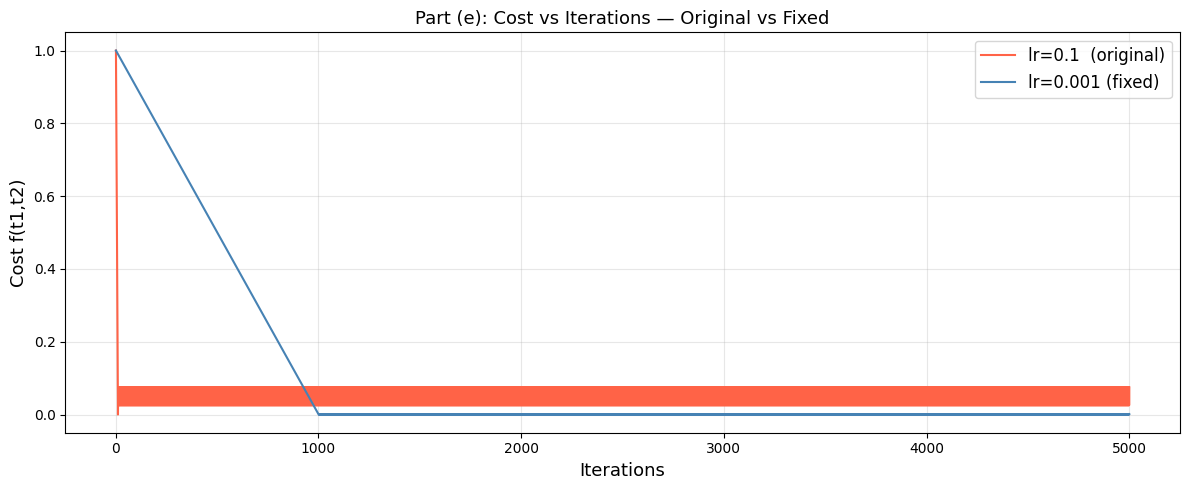

In [5]:
# ── Fix: smaller learning rate ──────────────────────────────────────────
learning_rate_fixed = 0.001          # reduced from 0.1
max_iter_fixed      = 5000

t1_old, t2_old = initial_t1, initial_t2
t1_list_f, t2_list_f, cost_list_f = [], [], []

for i in range(1, max_iter_fixed + 1):
    t1_new = t1_old - learning_rate_fixed * pdfx(t1_old, t2_old)
    t2_new = t2_old - learning_rate_fixed * pdfy(t1_old, t2_old)
    t1_list_f.append(t1_old)
    t2_list_f.append(t2_old)
    cost_list_f.append(f(t1_old, t2_old))
    t1_old, t2_old = t1_new, t2_new

print('=' * 52)
print('  Part (e): Fixed (learning_rate = 0.001)')
print('=' * 52)
print(f'  Number of iterations   : {i}')
print(f'  Final t1               : {t1_new:.8f}')
print(f'  Final t2               : {t2_new:.8f}')
print(f'  Cost  f(t1,t2)         : {f(t1_new,t2_new):.8f}')
print('=' * 52)

# Side-by-side cost curves
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(cost_list)+1),   cost_list,   color='tomato',    label='lr=0.1  (original)')
plt.plot(range(1, len(cost_list_f)+1), cost_list_f, color='steelblue', label='lr=0.001 (fixed)')
plt.xlabel('Iterations', fontsize=13)
plt.ylabel('Cost f(t1,t2)', fontsize=13)
plt.title('Part (e): Cost vs Iterations — Original vs Fixed', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part (f) — Cost vs Iterations for various learning rates → Find optimal

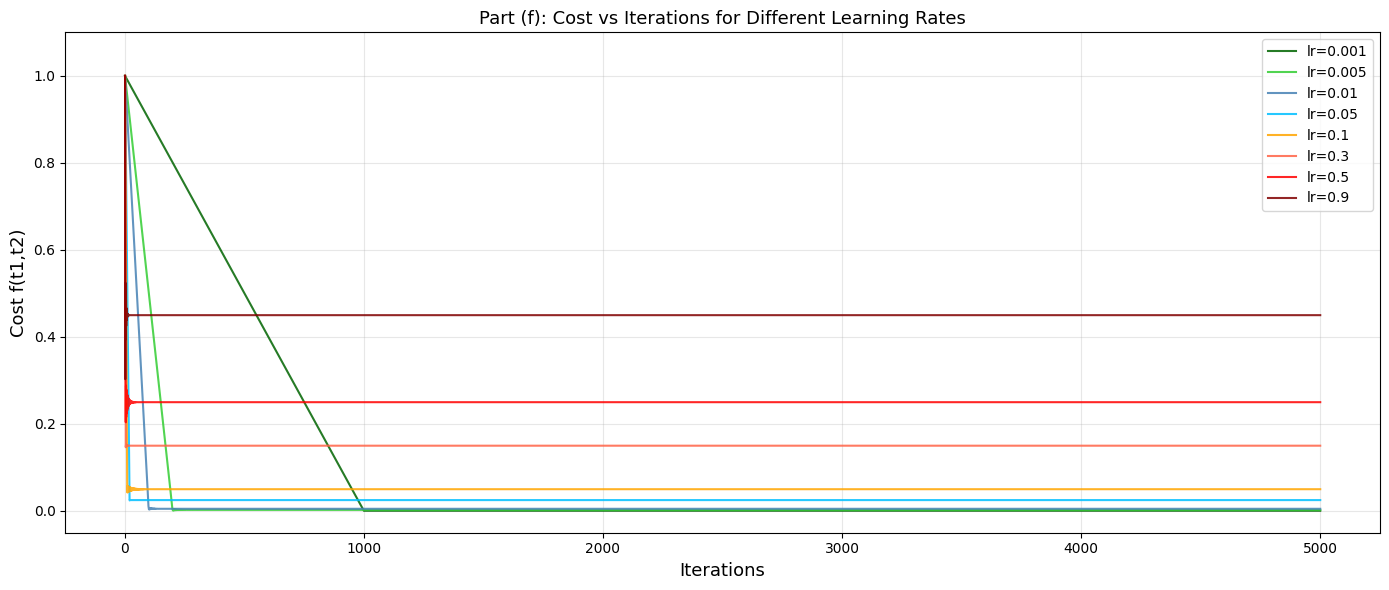

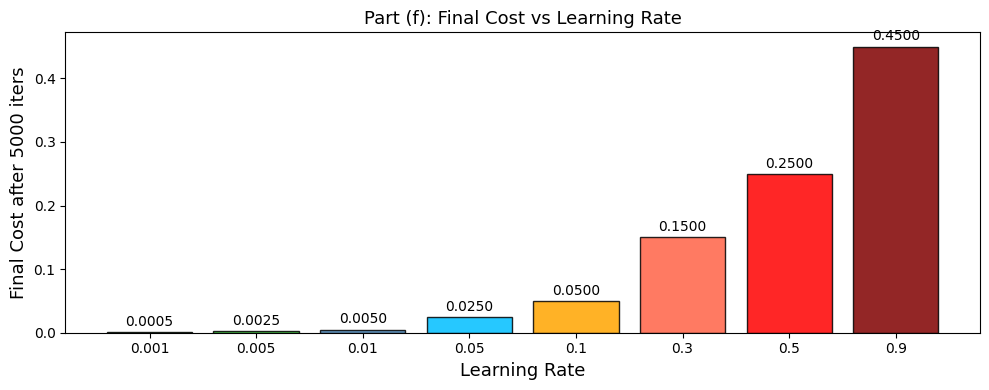

  Learning Rate  |  Final Cost
  lr = 0.001     |  0.000500 ← OPTIMAL
  lr = 0.005     |  0.002500
  lr = 0.01      |  0.005000
  lr = 0.05      |  0.025000
  lr = 0.1       |  0.050000
  lr = 0.3       |  0.150000
  lr = 0.5       |  0.250000
  lr = 0.9       |  0.450000


In [6]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 0.9]
colors = ['darkgreen','limegreen','steelblue','deepskyblue','orange','tomato','red','maroon']
final_costs = []

plt.figure(figsize=(14, 6))

for lr, col in zip(learning_rates, colors):
    t1_old2, t2_old2 = initial_t1, initial_t2
    costs = []
    for j in range(1, 5001):
        costs.append(f(t1_old2, t2_old2))
        t1_old2 = t1_old2 - lr * pdfx(t1_old2, t2_old2)
        t2_old2 = t2_old2 - lr * pdfy(t1_old2, t2_old2)
    final_costs.append(f(t1_old2, t2_old2))
    plt.plot(range(1, 5001), costs, color=col, label=f'lr={lr}', alpha=0.85)

plt.xlabel('Iterations', fontsize=13)
plt.ylabel('Cost f(t1,t2)', fontsize=13)
plt.title('Part (f): Cost vs Iterations for Different Learning Rates', fontsize=13)
plt.legend(fontsize=10, loc='upper right')
plt.ylim(-0.05, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Bar chart of final cost per lr ──────────────────────────────────────
plt.figure(figsize=(10, 4))
bars = plt.bar([str(lr) for lr in learning_rates], final_costs,
               color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, final_costs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.xlabel('Learning Rate', fontsize=13)
plt.ylabel('Final Cost after 5000 iters', fontsize=13)
plt.title('Part (f): Final Cost vs Learning Rate', fontsize=13)
plt.tight_layout()
plt.show()

# ── Print summary ────────────────────────────────────────────────────────
print('=' * 45)
print('  Learning Rate  |  Final Cost')
print('=' * 45)
for lr, fc in zip(learning_rates, final_costs):
    star = ' ← OPTIMAL' if fc == min(final_costs) else ''
    print(f'  lr = {str(lr):<8}  |  {fc:.6f}{star}')
print('=' * 45)